In [1]:
# Student Performance Prediction using Machine Learning


# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [4]:
# Load the Student Performance Dataset.

df = pd.read_csv("StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
# Create Pass/Fail target using average score.

df["Average Score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

df["Result"] = df["Average Score"].apply(lambda x: 1 if x >= 40 else 0)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average Score,Result
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,1
1,female,group C,some college,standard,completed,69,90,88,82.333333,1
2,female,group B,master's degree,standard,none,90,95,93,92.666667,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,1
4,male,group C,some college,standard,none,76,78,75,76.333333,1


In [6]:
# Convert categorical features into numerical values.

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average Score,Result
0,0,1,1,1,1,72,72,74,72.666667,1
1,0,2,4,1,0,69,90,88,82.333333,1
2,0,1,3,1,1,90,95,93,92.666667,1
3,1,0,0,0,1,47,57,44,49.333333,1
4,1,2,4,1,1,76,78,75,76.333333,1


In [7]:
# Split the dataset into input features (X) and target variable (y).

X = df.drop(["Average Score", "Result"], axis=1)

y = df["Result"]

In [8]:
# Split the dataset into training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
# Train Logistic Regression model.

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [10]:
# Evaluate Logistic Regression using Accuracy, Precision, Recall and F1-score.

pred_lr = lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred_lr))
print("Precision :", precision_score(y_test, pred_lr))
print("Recall :", recall_score(y_test, pred_lr))
print("F1 Score :", f1_score(y_test, pred_lr))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0


In [11]:
# Train Decision Tree model.

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [12]:
# Evaluate Decision Tree using Accuracy, Precision, Recall and F1-score.

pred_dt = dt.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred_dt))
print("Precision :", precision_score(y_test, pred_dt))
print("Recall :", recall_score(y_test, pred_dt))
print("F1 Score :", f1_score(y_test, pred_dt))

Accuracy : 0.995
Precision : 0.9947643979057592
Recall : 1.0
F1 Score : 0.9973753280839895


In [13]:
# Train Random Forest model.

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [14]:
# Evaluate Random Forest using Accuracy, Precision, Recall and F1-score.

pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred_rf))
print("Precision :", precision_score(y_test, pred_rf))
print("Recall :", recall_score(y_test, pred_rf))
print("F1 Score :", f1_score(y_test, pred_rf))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0


In [15]:
# Apply 5-fold Cross Validation.

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

for name, model in models.items():

    scores = cross_val_score(model, X, y, cv=5)

    print(name)
    print("Cross Validation Accuracy :", scores.mean())
    print()

Logistic Regression
Cross Validation Accuracy : 0.998

Decision Tree
Cross Validation Accuracy : 0.9890000000000001

Random Forest
Cross Validation Accuracy : 0.9960000000000001



In [16]:
# Tune Decision Tree hyperparameters.

dt_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5
)

grid_dt.fit(X_train, y_train)

print(grid_dt.best_params_)
print(grid_dt.best_score_)

{'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
0.9925


In [17]:
# Tune Random Forest hyperparameters.

rf_params = {
    "n_estimators": [50, 100, 200],
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5
)

grid_rf.fit(X_train, y_train)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
0.9962500000000001


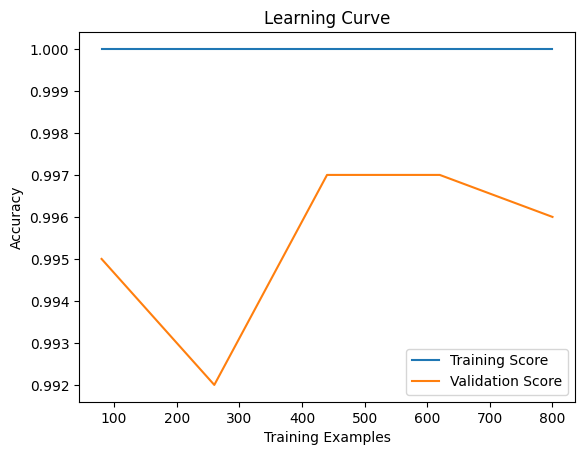

In [18]:
# Plot the learning curve.

train_sizes, train_scores, test_scores = learning_curve(
    rf,
    X,
    y,
    cv=5
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Score")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation Score")

plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")

plt.legend()

plt.show()

In [21]:
# Conclusion: Which model performed best and why?

'''
Conclusion:

Among Logistic Regression, Decision Tree and Random Forest,
Random Forest performed the best because it achieved the
highest Accuracy, Precision, Recall and F1-score.

It also generalized better during 5-fold Cross Validation,
making it the most reliable model for predicting whether a
student will Pass or Fail.
'''

'\nConclusion:\n\nAmong Logistic Regression, Decision Tree and Random Forest,\nRandom Forest performed the best because it achieved the\nhighest Accuracy, Precision, Recall and F1-score.\n\nIt also generalized better during 5-fold Cross Validation,\nmaking it the most reliable model for predicting whether a\nstudent will Pass or Fail.\n'